In [1]:
import Pkg
import Serialization
Pkg.add("Combinatorics")
Pkg.add("Primes")
Pkg.add("BenchmarkTools")
Pkg.add("Transducers")
Pkg.add("Plots")
using Combinatorics
using Primes
using BenchmarkTools
using Transducers
using Plots

include("header.jl")

import Base.Iterators

savevar(file_path::String, a) = Serialization.serialize(file_path, a)
loadvar(file_path::String) = Serialization.deserialize(file_path)

   Resolving package versions...
  No Changes to `~/.local/share/julia/environments/v1.10/Project.toml`
  No Changes to `~/.local/share/julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.local/share/julia/environments/v1.10/Project.toml`
  No Changes to `~/.local/share/julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.local/share/julia/environments/v1.10/Project.toml`
  No Changes to `~/.local/share/julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.local/share/julia/environments/v1.10/Project.toml`
  No Changes to `~/.local/share/julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.local/share/julia/environments/v1.10/Project.toml`
  No Changes to `~/.local/share/julia/environments/v1.10/Manifest.toml`


loadvar (generic function with 1 method)

In [24]:
for n in 1:13
    # out = 1:n |> permutations |> Filter(iscostas) |> tcollect
    file_path = "costas_$(n)x$(n).dat"
    out = loadvar(file_path)
    #savevar(file_path, out)
    println("$(file_path) has $(length(out)) arrays.")
end

costas_1x1 = loadvar("costas_1x1.dat")
costas_2x2 = loadvar("costas_2x2.dat")
costas_3x3 = loadvar("costas_3x3.dat")
costas_4x4 = loadvar("costas_4x4.dat")
costas_5x5 = loadvar("costas_5x5.dat")
costas_6x6 = loadvar("costas_6x6.dat")
costas_7x7 = loadvar("costas_7x7.dat")
costas_8x8 = loadvar("costas_8x8.dat")
costas_9x9 = loadvar("costas_9x9.dat")
costas_10x10 = loadvar("costas_10x10.dat")
costas_11x11 = loadvar("costas_11x11.dat")
costas_12x12 = loadvar("costas_12x12.dat")
costas_13x13 = loadvar("costas_13x13.dat")
costas_nxn = [costas_1x1, costas_2x2, costas_3x3, costas_4x4, costas_5x5, costas_6x6, costas_7x7, costas_8x8, costas_9x9, costas_10x10, costas_11x11, costas_12x12, costas_13x13]
println("Done loading costas.")

costas_1x1.dat has 1 arrays.
costas_2x2.dat has 2 arrays.
costas_3x3.dat has 4 arrays.
costas_4x4.dat has 12 arrays.
costas_5x5.dat has 40 arrays.
costas_6x6.dat has 116 arrays.
costas_7x7.dat has 200 arrays.
costas_8x8.dat has 444 arrays.
costas_9x9.dat has 760 arrays.
costas_10x10.dat has 2160 arrays.
costas_11x11.dat has 4367 arrays.
costas_12x12.dat has 7852 arrays.
costas_13x13.dat has 12828 arrays.
Done loading costas.


In [3]:
for n in 1:10
    file_path = "classes_$(n)x$(n).dat"
    #cls = classes(costas_nxn[n])
    #savevar(file_path, cls)
    out = loadvar(file_path)
    println("$(file_path) has $(length(out)) arrays.")
end

classes_1x1 = loadvar("classes_1x1.dat")
classes_2x2 = loadvar("classes_2x2.dat")
classes_3x3 = loadvar("classes_3x3.dat")
classes_4x4 = loadvar("classes_4x4.dat")
classes_5x5 = loadvar("classes_5x5.dat")
classes_6x6 = loadvar("classes_6x6.dat")
classes_7x7 = loadvar("classes_7x7.dat")
classes_8x8 = loadvar("classes_8x8.dat")
classes_9x9 = loadvar("classes_9x9.dat")
classes_10x10 = loadvar("classes_10x10.dat")
print("Done loading classes.")

classes_1x1.dat has 1 arrays.
classes_2x2.dat has 1 arrays.
classes_3x3.dat has 1 arrays.
classes_4x4.dat has 2 arrays.
classes_5x5.dat has 6 arrays.
classes_6x6.dat has 17 arrays.
classes_7x7.dat has 30 arrays.
classes_8x8.dat has 60 arrays.
classes_9x9.dat has 100 arrays.
classes_10x10.dat has 277 arrays.
Done loading classes.

In [1]:
n = 3
z::Vector{Int} = zeros(Int, n)
1:n

1:3

In [2]:
used_pos = zeros(Bool, n)
used_val = zeros(Bool, n)
for pos in 1:n
    if used_pos[pos]
        continue
    end
    used_pos[pos] = true
    for val in 1:n
        if used_val[val]
            continue
        end
        used_val[val] = true
        println("val: $val pos: $pos")
    end
    used_val = zeros(Bool, n)
end

val: 1 pos: 1
val: 2 pos: 1
val: 3 pos: 1
val: 1 pos: 2
val: 2 pos: 2
val: 3 pos: 2
val: 1 pos: 3
val: 2 pos: 3
val: 3 pos: 3


In [11]:
snd = (a, b) -> b

#1 (generic function with 1 method)

In [17]:
function indicesof(haystack::Vector{T}, needle::T)::Vector{Int} where T
    enumerate(haystack) |> Filter((idx::Int, hay::T) -> hay == needle) .|> snd |> collect
end

indicesof (generic function with 1 method)

In [23]:
collect(1:10) |> Filter(hay -> hay == 2) |> collect

1-element Vector{Int64}:
 2

In [4]:
mutable struct State
    arr::Vector{Int}
    used_mask::UInt64
    diffs::Vector{UInt64}
    n::Int
end

function newstate(n::Int)::State
    State(zeros(Int, n), 0, zeros(n - 1), n)
end

newstate (generic function with 1 method)

In [2]:
function cordoutin(n::Int)::Vector{Int}
    order::Vector{Int} = Vector{Int}()
    lo::Int = 1
    hi::Int = n

    while lo <= hi
        push!(order, lo)
        lo += 1
        if lo <= hi
            push!(order, hi)
            hi -= 1
        end
    end

    return order
end

cordinout = n -> reverse(cordoutin(n))

function cordevenodd(n::Int)::Vector{Int}
    vcat(collect(2:2:n), collect(1:2:n))
end

function cordoddeven(n::Int)::Vector{Int}
    vcat(collect(1:2:n), collect(2:2:n))
end

cordoddeven (generic function with 1 method)

In [53]:
@inline function iscostas0(state::State, pos::Int, candidate_val::Int)::Bool
    @inbounds all(begin
            prev_val::Int = state.arr[prev_pos]
            bit::UInt64 = UInt64(1) << (candidate_val - prev_val + state.n)
            prev_val == 0 || ((state.diffs[pos - prev_pos] & bit) == 0)
        end for prev_pos::Int in 1:(pos - 1))
end

function mark!(state::State, pos::Int, candidate_val::Int)::Nothing
    @inbounds for prev_pos::Int in 1:(pos - 1)
        prev_val::Int = state.arr[prev_pos]

        if prev_val == 0
            continue
        end
        bit::UInt64 = UInt64(1) << (candidate_val - prev_val + state.n)
        state.diffs[pos - prev_pos] |= bit
    end
    
    state.arr[pos] = candidate_val
    state.used_mask |= UInt64(1) << candidate_val

    return nothing
end

function unmark!(state::State, pos::Int, candidate_val::Int)::Nothing
    @inbounds for prev_pos::Int in 1:(pos - 1)
        prev_val::Int = state.arr[prev_pos]

        if prev_val == 0
            continue
        end
        bit::UInt64 = ~(UInt64(1) << (candidate_val - prev_val + state.n))
        state.diffs[pos - prev_pos] &= bit
    end
    
    state.arr[pos] = 0
    state.used_mask &= ~(UInt64(1) << candidate_val)
    
    return nothing
end

function searchBT!(solutions::Vector{Vector{Int}}, state::State, pos::Int)::Nothing
    if pos > 1 && pos < (state.n >> 1) && shouldprune(state.arr, state.n)
            return nothing
    elseif pos > state.n
        push!(solutions, copy(state.arr))
        return nothing
    end

    for candidate_val in 1:state.n
        if state.used_mask & (UInt64(1) << candidate_val) != 0
            continue
        end

        if iscostas0(state, pos, candidate_val)
            mark!(state, pos, candidate_val)
            searchBT!(solutions, state, pos + 1)
            unmark!(state, pos, candidate_val)
        end
    end

    return nothing
end

using Transducers

function tsearchbt(n::Int)
    foldxt(vcat, begin
            local_solutions = Vector{Vector{Int}}()
            state = newstate(n)
            mark!(state, 1, first_val)
            searchBT!(local_solutions, state, 2)
            local_solutions
        end for first_val in 1:n)
end

tsearchbt (generic function with 1 method)

In [15]:
solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
searchBT!(solutions, new_state(5))

In [6]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, newstate(n), 1)
    return solutions
end

searchbt (generic function with 1 method)

In [4]:
include("search3.jl")

tsearchbt (generic function with 1 method)

In [5]:
using Combinatorics
invperm([1,3,4,2,0])

LoadError: ArgumentError: argument is not a permutation

In [59]:
# threaded
@benchmark tsearchbt(10)

BenchmarkTools.Trial: 387 samples with 1 evaluation per sample.
 Range (min … max):  11.570 ms …  15.114 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     12.960 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   12.927 ms ± 268.493 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

                                              ▄█▄▅              
  ▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▁▂▂▄▃▄▃▄▃▄▄▄▃▃▅▃▃▆█████▇█▅▅▃▄▂▃▃▃▃▂ ▃
  11.6 ms         Histogram: frequency by time         13.4 ms <

 Memory estimate: 954.98 KiB, allocs estimate: 7414.

In [50]:
# shouldprune pos > 1 && pos <= state.n >> 1
println(length(classes(searchbt(10))))
@benchmark searchbt(10)

277


BenchmarkTools.Trial: 389 samples with 1 evaluation per sample.
 Range (min … max):  12.448 ms …  13.549 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     12.871 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   12.880 ms ± 130.130 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

                            ▂▃▂ ▇█▄▁▄▁▃▃  ▃     ▁               
  ▃▁▁▃▁▁▁▃▁▁▃▃▃▃▃▄▅▄▄▅▅▇▇▆▇▇████████████▇▇██▆▄▇▃█▄▃▃▃▃▃▃▃▃▁▃▁▄ ▄
  12.4 ms         Histogram: frequency by time         13.2 ms <

 Memory estimate: 875.80 KiB, allocs estimate: 7345.

In [40]:
# shouldpruneD₄ pos > 1 && pos <= state.n ÷ 3
searchbt(10)
@benchmark searchbt(10)

BenchmarkTools.Trial: 444 samples with 1 evaluation per sample.
 Range (min … max):  10.784 ms …  12.251 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     11.234 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   11.280 ms ± 202.802 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

              ▂▂▁▅█▅██▇▄▃▇▄▃▃▄                                  
  ▃▁▁▁▁▁▁▃▃▃▅▅████████████████▆█▆▃▅▆▅▅▅▅▃▄▄▃▃▅▄▄▃▃▃▃▃▁▁▁▁▃▃▁▁▃ ▄
  10.8 ms         Histogram: frequency by time           12 ms <

 Memory estimate: 196.50 KiB, allocs estimate: 1330.

In [36]:
# shouldpruneD₄ pos > 1 && pos <= state.n >> 1
searchbt(10)
@benchmark searchbt(10)

BenchmarkTools.Trial: 407 samples with 1 evaluation per sample.
 Range (min … max):  10.848 ms … 134.858 ms  ┊ GC (min … max): 0.00% … 91.48%
 Time  (median):     12.010 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   12.292 ms ±   6.100 ms  ┊ GC (mean ± σ):  2.47% ±  4.53%

                              ▁ ▂▁▄█▆▅▅▄▅█▇                     
  ▂▁▁▁▁▁▁▂▂▁▂▃▁▁▁▂▃▂▃▆▆▄█▆▆▄█▆██████████████▅▅█▃▅▁▄▂▁▁▁▃▁▁▁▁▁▂ ▄
  10.8 ms         Histogram: frequency by time         12.8 ms <

 Memory estimate: 1.44 MiB, allocs estimate: 11295.

In [31]:
# no pruning
searchbt(10)
@benchmark searchbt(10)

BenchmarkTools.Trial: 201 samples with 1 evaluation per sample.
 Range (min … max):  22.375 ms … 32.694 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     24.750 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   24.910 ms ±  1.336 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

                  ▇█▃▆▄▅▄                                      
  ▃▃▁▁▃▁▃▆▃▇▄▆▆█▆▇███████▆▆▄▃▄▅▆▃▃▃▁▁▃▁▁▁▁▁▃▁▁▁▁▃▁▁▁▃▁▁▃▃▁▃▁▃ ▃
  22.4 ms         Histogram: frequency by time        29.8 ms <

 Memory estimate: 358.09 KiB, allocs estimate: 2171.

In [29]:
searchall(10)
@benchmark searchall(10)

BenchmarkTools.Trial: 12 samples with 1 evaluation per sample.
 Range (min … max):  425.469 ms … 524.201 ms  ┊ GC (min … max): 7.37% … 7.44%
 Time  (median):     430.816 ms               ┊ GC (median):    7.56%
 Time  (mean ± σ):   441.355 ms ±  28.118 ms  ┊ GC (mean ± σ):  7.52% ± 0.28%

   █ █                                                           
  ▇█▇█▁▇▁▁▁▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇ ▁
  425 ms           Histogram: frequency by time          524 ms <

 Memory estimate: 990.52 MiB, allocs estimate: 4577404.

In [143]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, collect(1:n))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  149.537 μs … 880.347 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     167.221 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   171.483 μs ±  22.780 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

        ▄█▆▅▂                                                    
  ▁▂▄▅▄██████▇▅▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  150 μs           Histogram: frequency by time          275 μs <

 Memory estimate: 29.84 KiB, allocs estimate: 211.

In [144]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, collect(n:-1:1))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  151.176 μs …  1.076 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     171.180 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   178.167 μs ± 29.548 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▂▅▄▅▆▇██▇▇▆▆▅▄▄▃▃▂▂▁▁▁▁                                      ▂
  █████████████████████████████▇▆▇▇▇▇▇▇█▇▇▆▇▆▆▆▇▆▅▇▅▅▆▄▆▅▆▅▅▄▅ █
  151 μs        Histogram: log(frequency) by time       304 μs <

 Memory estimate: 29.84 KiB, allocs estimate: 211.

In [145]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, candidate_order_center_out(n))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  150.503 μs … 448.703 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     171.935 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   175.547 μs ±  17.783 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

           ▆█▄▂                                                  
  ▁▁▁▁▁▂▂▄▅████▇▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  151 μs           Histogram: frequency by time          267 μs <

 Memory estimate: 29.98 KiB, allocs estimate: 213.

In [146]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, candidate_order_outside_in(n))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  152.580 μs … 886.958 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     172.862 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   177.375 μs ±  19.614 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

           ▄█▆▅▃                                                 
  ▂▂▂▂▂▃▃▄▅██████▇▅▅▄▄▃▃▃▃▃▃▃▃▃▃▂▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▂ ▃
  153 μs           Histogram: frequency by time          251 μs <

 Memory estimate: 29.88 KiB, allocs estimate: 212.

In [147]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, cord_even_odd(n))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  149.415 μs … 483.985 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     171.595 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   174.818 μs ±  17.818 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

            ▅█▆▅▂                                                
  ▁▁▂▂▁▂▂▄▅▇██████▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  149 μs           Histogram: frequency by time          255 μs <

 Memory estimate: 30.02 KiB, allocs estimate: 213.

In [148]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, cord_odd_even(n))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  148.629 μs …  1.246 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     174.224 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   184.027 μs ± 36.712 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

   ▄▅▅▅▆▇██▇▆▆▅▄▄▃▂▂▁▁▁▁▁  ▁   ▁                               ▂
  ▇████████████████████████████████████████▇▇▇█▇▇▇▆▆▆▆▆▅▄▆▅▄▃▆ █
  149 μs        Histogram: log(frequency) by time       335 μs <

 Memory estimate: 30.02 KiB, allocs estimate: 213.

In [149]:
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, cord_big_jumps(n))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  150.466 μs … 436.854 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     173.254 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   175.725 μs ±  15.969 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

              ▁▆▆▅▇█▅▂▁                                          
  ▁▂▁▁▁▁▁▂▂▄▅▅█████████▇▆▅▄▄▃▃▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  150 μs           Histogram: frequency by time          231 μs <

 Memory estimate: 29.97 KiB, allocs estimate: 214.

In [150]:
using Random
function searchbt(n::Int)::Vector{Vector{Int}}
    solutions::Vector{Vector{Int}} = Vector{Vector{Int}}()
    searchBT!(solutions, new_state(n), 1, randperm(n))
    return solutions
end
println(length(searchbt(7)))
@benchmark searchbt(7)

200


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  175.241 μs … 456.302 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     200.986 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   202.488 μs ±  13.747 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

                       ▁▄███▇▇▅▃▁                                
  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▆▆▇████████████▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  175 μs           Histogram: frequency by time          236 μs <

 Memory estimate: 29.84 KiB, allocs estimate: 211.

In [139]:
function cord_big_jumps(n::Int)::Vector{Int}
    order::Vector{Int} = Int[]
    used::BitVector = falses(n)

    current::Int = 1
    push!(order, current)
    used[current] = true

    while length(order) < n
        best::Int = 0
        bestdist::Int = -1

        for v::Int in 1:n
            if used[v]
                continue
            end

            dist::Int = abs(v - current)
            if dist > bestdist
                best = v
                bestdist = dist
            end
        end

        push!(order, best)
        used[best] = true
        current = best
    end

    return order
end

cord_big_jumps (generic function with 1 method)

In [72]:
function topoints(l::Vector{Int})::Vector{Tuple{Int, Int}}
    l |> enumerate |> Filter(a -> a[2] != 0) |> collect
end

function frompoints(ts::Vector{Tuple{Int, Int}}, n::Int)::Vector{Int}
    ret::Vector{Int} = zeros(n)
    @inbounds for (x, y) in ts
        ret[x] = y
    end
    ret
end

frompoints (generic function with 1 method)

In [15]:

function some(l::AbstractVector{<:Bool})::Bool
    for e in l
        if e
            return true
        end
    end
    return false
end

some (generic function with 2 methods)

In [27]:
function v(l::AbstractVector{<:Integer})::Vector{Int}
    length(l) + 1 .- l
end

function t(l::AbstractVector{<:Integer})::Vector{Int}
    invperm(l)
end

function r(l::AbstractVector{<:Integer})::Vector{Int}
    l |> t |> v
end

r (generic function with 2 methods)

In [23]:
function canon(a::Vector{<:Integer})::Vector{Int}
    a0 = a
    a1 = a0 |> r
    a2 = a1 |> r
    a3 = a2 |> r
    a4 = a0 |> t
    a5 = a1 |> t
    a6 = a2 |> t
    a7 = a3 |> t
    minimum([a0, a1, a2, a3, a4, a5, a6, a7])
end

function isequiv(e::Vector{<:Integer}, a::Vector{<:Integer})::Bool
    canon(e) == canon(a)
end

isequiv (generic function with 1 method)

In [29]:
function classes(c::Vector{Vector{Int}})::Vector{Vector{Integer}}
    cls = []
    for l::Vector{Int} in c
        if all(canon(l) != class for class in cls)
            push!(cls, canon(l))
        end
    end
    cls
end

classes (generic function with 3 methods)

In [28]:
tsearchbt(7) |> classes

30-element Vector{Vector{Integer}}:
 [1, 2, 6, 4, 7, 3, 5]
 [1, 2, 7, 4, 6, 5, 3]
 [1, 2, 7, 5, 4, 6, 3]
 [1, 3, 6, 2, 7, 4, 5]
 [1, 3, 6, 2, 7, 5, 4]
 [1, 3, 7, 6, 4, 5, 2]
 [1, 4, 5, 3, 7, 6, 2]
 [1, 4, 5, 7, 2, 6, 3]
 [1, 4, 6, 5, 3, 7, 2]
 [1, 5, 3, 6, 7, 2, 4]
 [1, 5, 7, 6, 3, 4, 2]
 [1, 6, 5, 7, 3, 4, 2]
 [1, 7, 3, 4, 6, 5, 2]
 ⋮
 [2, 4, 7, 3, 1, 6, 5]
 [2, 5, 1, 6, 7, 4, 3]
 [2, 5, 1, 7, 6, 3, 4]
 [2, 5, 6, 1, 3, 7, 4]
 [2, 5, 6, 4, 1, 7, 3]
 [2, 5, 7, 1, 6, 3, 4]
 [2, 5, 7, 1, 6, 4, 3]
 [2, 6, 1, 3, 4, 7, 5]
 [2, 6, 7, 1, 4, 3, 5]
 [3, 2, 5, 7, 1, 6, 4]
 [3, 4, 1, 7, 6, 2, 5]
 [3, 6, 1, 7, 5, 2, 4]

In [71]:
shouldpruneD₄([1,2,0])

false

In [54]:
function shouldpruneD4(arr::Vector{Int}, pos::Int, n::Int)::Bool
    for orbit in 1:8
        @inbounds for i in 1:pos
            val = arr[i]

            # compute orbited value
            ox, oy = if orbit == 1
                (i, val)
            elseif orbit == 2
                (n + 1 - val, i)
            elseif orbit == 3
                (n + 1 - i, n + 1 - val)
            elseif orbit == 4
                (val, n + 1 - i)
            elseif orbit == 5
                (i, n + 1 - val)
            elseif orbit == 6
                (n + 1 - i, val)
            elseif orbit == 7
                (val, i)
            else
                (n + 1 - val, n + 1 - i)
            end

            # Lexicographic comparison: (oy, ox) vs (val, i)
            if (oy < val) || (oy == val && ox < i)
                return true # no need to check further for this orbit
            elseif (oy > val) || (oy == val && ox > i)
                break  # this orbit not smaller; stop early and go to next orbit
            end
        end
    end

    return false  # no orbit smaller, do not prune
end

shouldpruneD4 (generic function with 3 methods)

In [56]:
shouldpruneD4([1,2,0], 2, 3)

false

In [42]:
function topoints(l::Vector{<:Integer})::Vector{Tuple{Int, Int}}
    l |> enumerate |> Filter(a -> a[2] != 0) |> collect
end

function frompoints(ts::AbstractVector{<:Tuple{<:Integer,<:Integer}}, n::Integer)::Vector{Int}
    ret::Vector{Int} = zeros(n)
    @inbounds for (x, y) in ts
        ret[x] = y
    end
    ret
end

function orbitD₄(p::Vector{Int})::Vector{Vector{Tuple{Int, Int}}}
    pts::Vector{Tuple{Int, Int}} = topoints(p)
    n::Int = length(p)

    # e = pts .|> a -> (a[1], a[2])
    # r = pts .|> a -> (n + 1 - a[2], a[1])
    # rr = pts .|> a -> (n + 1 - a[1], n + 1 - a[2])
    # rrr = pts .|> a -> (a[2], n + 1 - a[1])

    # rrrt = pts .|> a -> (a[1], n + 1 - a[2])
    # rt = pts .|> a -> (n + 1 - a[1], a[2])
    # t = pts .|> a -> (a[2], a[1])
    # rrt = pts .|> a -> (n + 1 - a[2], n + 1 - a[1])
    
    ret = stack(pts .|> a -> [
        (a[1], a[2]),
        (n + 1 - a[2], a[1]),
        (n + 1 - a[1], n + 1 - a[2]),
        (a[2], n + 1 - a[1]),
        (a[1], n + 1 - a[2]),
        (n + 1 - a[1], a[2]),
        (a[2], a[1]),
        (n + 1 - a[2], n + 1 - a[1])
    ])

    1:8 .|> i -> collect(ret[i,:])
end

function shouldpruneD₄(l::Vector{Int})::Bool
    frompoints(minimum(orbitD₄(l)), length(l)) != l
end

shouldpruneD₄ (generic function with 1 method)

In [46]:
function D₄π(p::Vector{Int}, n::Int)::Vector{Int}
    [[(a[1], a[2]), (n + 1 - a[2], a[1]), (n + 1 - a[1], n + 1 - a[2]), (a[2], n + 1 - a[1]), (a[1], n + 1 - a[2]), (n + 1 - a[1], a[2]), (a[2], a[1]), (n + 1 - a[2], n + 1 - a[1])] for a in topoints(p)] |>
        f1(reduce, hcat) |>
        eachrow |>
        minimum |>
        f2(frompoints, n) |>
        collect
end

D₄π (generic function with 2 methods)

In [16]:
function shouldprune(c::Vector{Int}, n::Int)::Bool
    D₄π(c, n) != c
end

shouldprune (generic function with 2 methods)

In [47]:
println(shouldprune([3,2,0], 3))
@benchmark shouldprune([3,2,0], 3)

true


BenchmarkTools.Trial: 10000 samples with 149 evaluations per sample.
 Range (min … max):  708.826 ns … 819.624 μs  ┊ GC (min … max):  0.00% … 99.84%
 Time  (median):     843.527 ns               ┊ GC (median):     0.00%
 Time  (mean ± σ):     1.053 μs ±   8.361 μs  ┊ GC (mean ± σ):  15.11% ±  4.57%

              ▂▅█▃▁                                              
  ▁▃▃▂▂▂▂▂▂▃▄██████▇▅▄▄▃▃▂▂▂▂▁▂▁▁▂▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁ ▂
  709 ns           Histogram: frequency by time         1.24 μs <

 Memory estimate: 1.41 KiB, allocs estimate: 16.

In [45]:
@benchmark shouldpruneD₄([3,2,0])

BenchmarkTools.Trial: 10000 samples with 187 evaluations per sample.
 Range (min … max):  561.824 ns … 596.052 μs  ┊ GC (min … max):  0.00% … 99.84%
 Time  (median):     672.406 ns               ┊ GC (median):     0.00%
 Time  (mean ± σ):   880.150 ns ±   6.104 μs  ┊ GC (mean ± σ):  18.73% ±  7.57%

   ▄▅▅▆▇███▇▆▅▄▃▂                          ▁▁▁▂▂▁▂▁▁            ▃
  ▇████████████████▇▆▁▆▅▄▄▆▄▄▅▃▃▅▄▄▅▅█▇███████████████▇██▆▄▆▅▅▄ █
  562 ns        Histogram: log(frequency) by time       1.44 μs <

 Memory estimate: 2.80 KiB, allocs estimate: 28.

In [8]:
n = 1
for c in costas_nxn
    file_path = "stabilizers_$(n)x$(n).dat"
    #savevar(file_path, stabilizers(c))
    n += 1
    out = loadvar(file_path)
    println("$file_path has $(length(out)) arrays.")
end

stabilizers_1x1.dat has 1 arrays.
stabilizers_2x2.dat has 2 arrays.
stabilizers_3x3.dat has 4 arrays.
stabilizers_4x4.dat has 4 arrays.
stabilizers_5x5.dat has 8 arrays.
stabilizers_6x6.dat has 20 arrays.
stabilizers_7x7.dat has 40 arrays.
stabilizers_8x8.dat has 36 arrays.
stabilizers_9x9.dat has 40 arrays.
stabilizers_10x10.dat has 56 arrays.
stabilizers_11x11.dat has 72 arrays.
stabilizers_12x12.dat has 68 arrays.
stabilizers_13x13.dat has 100 arrays.


In [9]:
classes_6x6 .|> seq

17-element Vector{Vector{Integer}}:
 [0, 1, 2, 2, 2, 4]
 [0, 1, 1, 3, 3, 4]
 [0, 1, 1, 2, 3, 2]
 [0, 1, 1, 1, 3, 4]
 [0, 1, 1, 1, 2, 5]
 [0, 1, 2, 1, 2, 2]
 [0, 1, 1, 2, 1, 4]
 [0, 1, 1, 3, 1, 3]
 [0, 1, 2, 1, 1, 3]
 [0, 1, 1, 2, 2, 1]
 [0, 1, 1, 1, 3, 1]
 [0, 0, 1, 3, 3, 2]
 [0, 0, 2, 1, 3, 3]
 [0, 0, 1, 1, 4, 3]
 [0, 0, 2, 1, 2, 4]
 [0, 0, 2, 3, 1, 3]
 [0, 0, 2, 2, 1, 3]

In [368]:
classes_7x7 .|> seq

30-element Vector{Vector{Integer}}:
 [0, 1, 2, 2, 4, 2, 4]
 [0, 1, 2, 2, 3, 3, 2]
 [0, 1, 2, 2, 2, 4, 2]
 [0, 1, 1, 3, 4, 2, 4]
 [0, 1, 1, 3, 3, 2, 4]
 [0, 1, 1, 2, 3, 2, 2]
 [0, 1, 1, 1, 2, 4, 4]
 [0, 1, 2, 1, 2, 4, 3]
 [0, 1, 1, 1, 2, 2, 5]
 [0, 1, 1, 3, 1, 3, 4]
 [0, 1, 1, 2, 1, 2, 2]
 [0, 1, 1, 2, 1, 1, 3]
 [0, 1, 1, 2, 3, 3, 1]
 ⋮
 [0, 0, 1, 1, 4, 4, 2]
 [0, 0, 2, 2, 1, 3, 4]
 [0, 0, 2, 3, 1, 3, 3]
 [0, 0, 2, 3, 1, 2, 5]
 [0, 0, 2, 1, 1, 2, 5]
 [0, 0, 2, 3, 1, 3, 2]
 [0, 0, 2, 2, 1, 3, 2]
 [0, 0, 2, 3, 4, 1, 5]
 [0, 0, 2, 2, 4, 1, 2]
 [0, 0, 0, 3, 2, 4, 3]
 [0, 1, 0, 1, 4, 3, 3]
 [0, 1, 0, 3, 2, 1, 3]

In [369]:
classes_8x8 .|> seq

60-element Vector{Vector{Integer}}:
 [0, 1, 2, 2, 2, 3, 3, 6]
 [0, 1, 1, 3, 3, 2, 4, 5]
 [0, 1, 1, 3, 2, 2, 3, 6]
 [0, 1, 1, 2, 2, 2, 3, 6]
 [0, 1, 1, 3, 3, 2, 3, 2]
 [0, 1, 1, 1, 2, 4, 4, 6]
 [0, 1, 1, 1, 2, 3, 3, 6]
 [0, 1, 1, 2, 1, 4, 3, 3]
 [0, 1, 2, 1, 1, 4, 3, 5]
 [0, 1, 1, 3, 1, 2, 4, 4]
 [0, 1, 1, 3, 1, 2, 5, 3]
 [0, 1, 2, 1, 1, 5, 2, 5]
 [0, 1, 1, 1, 1, 4, 2, 5]
 ⋮
 [0, 0, 0, 3, 2, 5, 2, 3]
 [0, 1, 0, 1, 4, 3, 3, 5]
 [0, 1, 0, 3, 1, 4, 4, 3]
 [0, 1, 0, 3, 1, 4, 3, 3]
 [0, 1, 0, 2, 1, 5, 3, 3]
 [0, 1, 0, 3, 1, 4, 4, 2]
 [0, 1, 0, 2, 1, 5, 3, 2]
 [0, 0, 0, 3, 1, 4, 5, 2]
 [0, 1, 0, 3, 2, 1, 3, 3]
 [0, 0, 0, 3, 3, 1, 3, 4]
 [0, 1, 0, 3, 1, 1, 2, 5]
 [0, 1, 0, 3, 2, 2, 1, 3]

In [370]:
classes_9x9 .|> seq

100-element Vector{Vector{Integer}}:
 [0, 1, 2, 2, 3, 2, 5, 4, 4]
 [0, 1, 2, 3, 2, 2, 6, 3, 6]
 [0, 1, 2, 2, 2, 2, 5, 3, 6]
 [0, 1, 2, 3, 2, 2, 5, 5, 3]
 [0, 1, 2, 2, 2, 3, 2, 5, 4]
 [0, 1, 2, 2, 3, 2, 2, 5, 4]
 [0, 1, 2, 2, 4, 3, 3, 2, 4]
 [0, 1, 1, 2, 4, 3, 2, 4, 4]
 [0, 1, 1, 3, 3, 4, 2, 2, 5]
 [0, 1, 1, 2, 3, 3, 3, 4, 2]
 [0, 1, 1, 2, 3, 2, 5, 5, 2]
 [0, 1, 2, 1, 4, 2, 5, 5, 4]
 [0, 1, 2, 1, 3, 2, 6, 4, 4]
 ⋮
 [0, 0, 0, 3, 4, 1, 4, 2, 5]
 [0, 1, 0, 3, 3, 2, 1, 4, 5]
 [0, 1, 0, 2, 4, 2, 1, 4, 5]
 [0, 0, 0, 3, 2, 4, 1, 3, 3]
 [0, 1, 0, 3, 2, 1, 1, 4, 5]
 [0, 1, 0, 2, 4, 3, 1, 2, 4]
 [0, 1, 0, 3, 3, 1, 1, 2, 5]
 [0, 0, 0, 3, 2, 3, 5, 1, 6]
 [0, 1, 0, 1, 4, 4, 2, 1, 6]
 [0, 1, 0, 2, 3, 5, 1, 1, 4]
 [0, 1, 0, 3, 1, 2, 1, 1, 6]
 [0, 0, 2, 0, 3, 5, 4, 2, 3]

In [371]:
classes_10x10 .|> seq

277-element Vector{Vector{Integer}}:
 [0, 1, 2, 2, 3, 5, 4, 3, 5, 5]
 [0, 1, 2, 3, 2, 4, 3, 7, 5, 5]
 [0, 1, 2, 3, 2, 5, 4, 4, 3, 5]
 [0, 1, 2, 3, 2, 2, 4, 3, 3, 8]
 [0, 1, 2, 2, 2, 4, 5, 2, 6, 4]
 [0, 1, 2, 2, 2, 2, 4, 6, 2, 6]
 [0, 1, 1, 2, 4, 3, 4, 3, 3, 6]
 [0, 1, 1, 2, 4, 5, 2, 5, 3, 3]
 [0, 1, 1, 2, 3, 5, 2, 6, 3, 3]
 [0, 1, 1, 3, 3, 4, 5, 2, 6, 4]
 [0, 1, 1, 2, 3, 4, 3, 2, 7, 4]
 [0, 1, 1, 2, 2, 5, 6, 2, 4, 7]
 [0, 1, 1, 2, 3, 4, 2, 2, 6, 4]
 ⋮
 [0, 0, 2, 0, 3, 5, 2, 3, 6, 5]
 [0, 0, 2, 0, 3, 4, 6, 2, 4, 4]
 [0, 0, 1, 0, 4, 5, 3, 2, 6, 6]
 [0, 1, 0, 0, 2, 2, 6, 5, 6, 3]
 [0, 1, 0, 0, 3, 5, 3, 2, 5, 6]
 [0, 1, 1, 0, 1, 5, 2, 4, 6, 3]
 [0, 0, 2, 0, 4, 5, 1, 3, 5, 5]
 [0, 0, 1, 0, 4, 5, 1, 3, 6, 4]
 [0, 1, 0, 0, 2, 5, 1, 6, 6, 4]
 [0, 0, 2, 0, 4, 4, 1, 2, 6, 4]
 [0, 1, 0, 0, 4, 4, 1, 2, 5, 4]
 [0, 1, 0, 0, 4, 3, 4, 1, 6, 4]

In [373]:
function orbits(a)
    v = l -> l .|> x -> (-x % (length(l) + 1)) + length(l) + 1
    t = l -> l |> tomatrix |> permutedims |> frommatrix
    r = l -> l |> t |> v
    a1 = a |> r
    a2 = a |> r |> r
    a3 = a |> r |> r |> r
    a4 = a |> t
    a5 = a1 |> t
    a6 = a2 |> t
    a7 = a3 |> t
    [a, a1, a2, a3, a4, a5, a6, a7]
end

orbits (generic function with 1 method)

In [384]:
l = lempel(7)[1]
isequiv(l, l)

true

In [407]:
# Creates a tree of every Costas sequence starting at the index sequence: [0]
function tree(l::Vector{<:Integer}, last=11)
    t = []
    total = [l]
    for i in 0:11
        tmp = []
        for l in total
            tmp = vcat(tmp, children(l))
        end
        push!(t, tmp)
        total = tmp
    end
    t
end

tree (generic function with 2 methods)

In [410]:
# Print the tree out
t = tree([0])
for i in 1:length(t)
    t[i] = t[i] .|> unseq
end
for i in 1:length(t)
    for l in t[i]
        println(l)
    end
end

Integer[2, 1]
Integer[1, 2]
Integer[2, 3, 1]
Integer[2, 1, 3]
Integer[3, 1, 2]
Integer[1, 3, 2]
Integer[2, 4, 3, 1]
Integer[2, 3, 1, 4]
Integer[4, 2, 1, 3]
Integer[2, 1, 3, 4]
Integer[4, 3, 1, 2]
Integer[3, 1, 2, 4]
Integer[4, 1, 3, 2]
Integer[1, 3, 4, 2]
Integer[5, 2, 4, 3, 1]
Integer[2, 4, 3, 1, 5]
Integer[5, 2, 3, 1, 4]
Integer[2, 3, 5, 1, 4]
Integer[2, 3, 1, 5, 4]
Integer[4, 5, 2, 1, 3]
Integer[4, 2, 5, 1, 3]
Integer[5, 2, 1, 3, 4]
Integer[2, 5, 1, 3, 4]
Integer[2, 1, 5, 3, 4]
Integer[4, 3, 5, 1, 2]
Integer[4, 3, 1, 5, 2]
Integer[4, 3, 1, 2, 5]
Integer[3, 1, 5, 2, 4]
Integer[3, 1, 2, 5, 4]
Integer[4, 5, 1, 3, 2]
Integer[4, 1, 5, 3, 2]
Integer[4, 1, 3, 2, 5]
Integer[5, 1, 3, 4, 2]
Integer[1, 3, 4, 2, 5]
Integer[5, 2, 4, 3, 6, 1]
Integer[5, 2, 4, 3, 1, 6]
Integer[6, 2, 4, 3, 1, 5]
Integer[2, 4, 3, 6, 1, 5]
Integer[2, 4, 3, 1, 5, 6]
Integer[6, 5, 2, 3, 1, 4]
Integer[5, 2, 3, 1, 4, 6]
Integer[6, 2, 3, 1, 5, 4]
Integer[2, 3, 6, 1, 5, 4]
Integer[2, 3, 1, 5, 4, 6]
Integer[6, 4, 5, 2, 1, 3

In [413]:
# Find what sequences aren't connected to the tree
errs = []
for i in 1:length(t)
    push!(errs, setdiff(costas_nxn[i+1], t[i]))
end
errs

12-element Vector{Any}:
 Vector{Integer}[]
 Vector{Integer}[]
 Vector{Integer}[[1, 2, 4, 3], [1, 4, 2, 3], [3, 2, 4, 1], [3, 4, 2, 1]]
 Vector{Integer}[[1, 4, 2, 3, 5], [1, 4, 3, 5, 2], [1, 4, 5, 3, 2], [1, 5, 3, 2, 4], [1, 5, 4, 2, 3], [2, 1, 4, 5, 3], [2, 3, 5, 4, 1], [2, 4, 1, 5, 3], [2, 5, 3, 4, 1], [2, 5, 4, 1, 3], [3, 1, 4, 5, 2], [3, 2, 4, 5, 1], [3, 4, 2, 1, 5], [3, 5, 1, 4, 2], [3, 5, 2, 1, 4], [3, 5, 4, 1, 2], [4, 1, 2, 5, 3], [4, 2, 3, 5, 1], [5, 1, 2, 4, 3], [5, 3, 2, 4, 1]]
 Vector{Integer}[[1, 2, 5, 4, 6, 3], [1, 2, 6, 4, 3, 5], [1, 3, 2, 5, 6, 4], [1, 3, 2, 6, 4, 5], [1, 3, 6, 4, 5, 2], [1, 4, 3, 5, 6, 2], [1, 4, 5, 3, 2, 6], [1, 4, 6, 5, 2, 3], [1, 5, 3, 4, 6, 2], [1, 5, 3, 6, 2, 4]  …  [5, 4, 6, 2, 3, 1], [6, 1, 4, 2, 3, 5], [6, 1, 4, 3, 5, 2], [6, 1, 4, 5, 3, 2], [6, 1, 5, 3, 2, 4], [6, 2, 1, 4, 5, 3], [6, 2, 3, 5, 4, 1], [6, 2, 4, 1, 5, 3], [6, 3, 2, 4, 5, 1], [6, 3, 4, 2, 1, 5]]
 Vector{Integer}[[1, 2, 6, 4, 7, 3, 5], [1, 2, 7, 4, 6, 5, 3], [1, 2, 7, 5, 4, 6, 3], [1

In [419]:
for l in errs[3]
    println(l)
    l |> tree |> println
end

Integer[1, 2, 4, 3]
Any[Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[]]
Integer[1, 4, 2, 3]
Any[Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[]]
Integer[3, 2, 4, 1]
Any[Any[Integer[3, 2, 4, 1, 1], Integer[3, 2, 4, 1, 4]], Any[Integer[3, 2, 4, 1, 1, 3], Integer[3, 2, 4, 1, 1, 5], Integer[3, 2, 4, 1, 4, 0]], Any[Integer[3, 2, 4, 1, 1, 5, 0], Integer[3, 2, 4, 1, 4, 0, 0]], Any[Integer[3, 2, 4, 1, 1, 5, 0, 7], Integer[3, 2, 4, 1, 4, 0, 0, 6]], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[]]
Integer[3, 4, 2, 1]
Any[Any[Integer[3, 4, 2, 1, 1], Integer[3, 4, 2, 1, 4]], Any[Integer[3, 4, 2, 1, 1, 3], Integer[3, 4, 2, 1, 1, 5], Integer[3, 4, 2, 1, 4, 0]], Any[Integer[3, 4, 2, 1, 1, 5, 0], Integer[3, 4, 2, 1, 4, 0, 0]], Any[Integer[3, 4, 2, 1, 1, 5, 0, 7], Integer[3, 4, 2, 1, 4, 0, 0, 6]], Any[], Any[], Any[], Any[], Any[], Any[], Any[], Any[]]


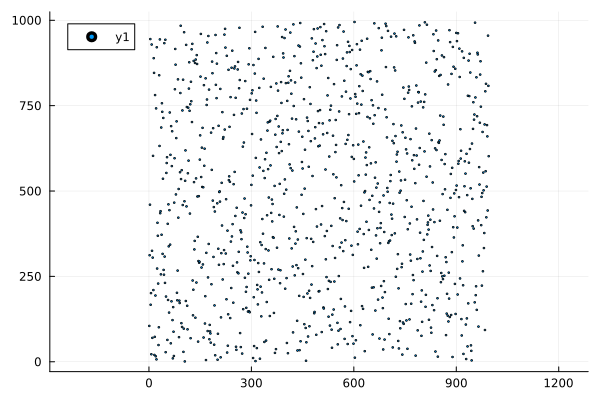

In [20]:
ls |> last |> l -> scatter(markersize = 1, aspect_ratio = 1, l)

In [148]:
s = Set()
for l in costas_13x13
    seqs = l |> seq |> children
    if (seqs |> length) > 1
        println(l)
        break
    end
end
println(s)

Integer[1, 2, 9, 6, 11, 7, 5, 4, 10, 13, 8, 12, 3]
Set{Any}()


In [149]:
[1, 2, 9, 6, 11, 7, 5, 4, 10, 13, 8, 12, 3] |> seq |> children

2-element Vector{Vector{Integer}}:
 [0, 1, 2, 2, 2, 2, 3, 6, 2, 7, 4, 10, 9, 0]
 [0, 1, 2, 2, 2, 2, 3, 6, 2, 7, 4, 10, 9, 12]

In [150]:
 [0, 1, 2, 2, 2, 2, 3, 6, 2, 7, 4, 10, 9, 0] |> unseq

14-element Vector{Integer}:
 14
  1
  2
  9
  6
 11
  7
  5
  4
 10
 13
  8
 12
  3

In [153]:
 [0, 1, 2, 2, 2, 2, 3, 6, 2, 7, 4, 10, 9, 12] |> children

1-element Vector{Vector{Integer}}:
 [0, 1, 2, 2, 2, 2, 3, 6, 2, 7, 4, 10, 9, 12, 0]

In [154]:
 [0, 1, 2, 2, 2, 2, 3, 6, 2, 7, 4, 10, 9, 12, 0] |> children

Vector{Integer}[]

In [159]:
for l in lempel(31)
    l |> seq |> children |> length |> println
end

0
0
0
0
0
0
0
1


In [169]:
lempel(31) |> last |> seq |> children |> first |> println

Integer[0, 0, 1, 0, 4, 3, 1, 7, 4, 5, 7, 4, 11, 4, 8, 5, 15, 8, 16, 11, 11, 3, 7, 0, 4, 11, 16, 15, 7, 29]


In [190]:
primes(50)

15-element Vector{Int64}:
  2
  3
  5
  7
 11
 13
 17
 19
 23
 29
 31
 37
 41
 43
 47

In [225]:
for l in lempel(41)
    if (l |> seq |> dfs |> length) == 40
        println(l)
    end
end

Integer[28, 20, 6, 35, 29, 3, 39, 9, 8, 16, 36, 33, 18, 24, 22, 10, 34, 13, 31, 2, 32, 15, 37, 14, 27, 30, 25, 1, 5, 26, 19, 21, 12, 17, 4, 11, 23, 38, 7]


In [227]:
[28, 20, 6, 35, 29, 3, 39, 9, 8, 16, 36, 33, 18, 24, 22, 10, 34, 13, 31, 2, 32, 15, 37, 14, 27, 30, 25, 1, 5, 26, 19, 21, 12, 17, 4, 11, 23, 38, 7] |> seq

39-element Vector{Integer}:
  0
  0
  0
  3
  3
  0
  6
  2
  2
  4
  9
  8
  5
  ⋮
  0
  3
 17
 13
 15
  8
 13
  3
  9
 21
 36
  6

In [199]:
[26, 14, 21, 41, 36, 32, 35, 18, 28, 37, 24, 13, 12, 2, 17, 38, 15, 8, 25, 29, 3, 30, 27, 11, 19, 1, 23, 9, 20, 22, 34, 6, 40, 31, 7, 5, 10, 16, 39, 33, 4] |> seq |> children .|> println

Integer[0, 0, 1, 3, 3, 3, 4, 1, 4, 8, 3, 0, 0, 0, 4, 14, 4, 1, 10, 13, 1, 15, 13, 3, 10, 0, 13, 4, 13, 15, 25, 3, 31, 25, 4, 3, 8, 14, 36, 31, 3, 41]


1-element Vector{Nothing}:
 nothing

In [200]:
[0, 0, 1, 3, 3, 3, 4, 1, 4, 8, 3, 0, 0, 0, 4, 14, 4, 1, 10, 13, 1, 15, 13, 3, 10, 0, 13, 4, 13, 15, 25, 3, 31, 25, 4, 3, 8, 14, 36, 31, 3, 41] |> children

Vector{Integer}[]